# Plotting

**Types of Plots (for our course)**

| Plot Type     | Description                                                  |
|---------------|--------------------------------------------------------------|
| Line Plot     | Shows how a value changes over time.                         |
| Bar Plot      | Compares values or properties across different groups.       |
| Histogram     | Displays the frequency distribution of a single variable.    |
| Scatter Plot  | Reveals relationships or correlations between two variables. |


**Each Plot Should Include:**

>- Title, X and Y Axis Labels
>- Legend when appropriate

**Optional Elements:**

>- Gridlines
>- Annontations
>- Color Palette
>- Figure size

**Libraries**

>- Matplotlib
>- Seaborn
>- Plotly

In [3]:
import pandas as pd

weather = pd.read_csv("weather.csv")

### Matplotlib

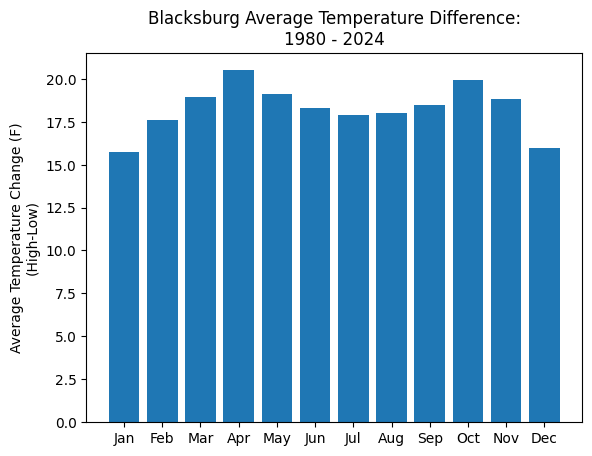

In [4]:
import matplotlib.pyplot as plt

# Filter the data
bburg_weather = weather[weather['city'] == 'Blacksburg'].copy()

# Transformation - adding a new column of data
#  difference of the max and min temps
bburg_weather['daily_diff'] = (bburg_weather['temp max'] - bburg_weather['temp min'])

# Grouping by month and aggregate mean over the temp difference
yearly_diff = bburg_weather.groupby("month")["daily_diff"].mean()

# Matplotlib Bar Chart with title, x and y axis labels
fig, ax = plt.subplots()
yearly_diff.index = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
ax.bar(yearly_diff.index, yearly_diff)

ax.set_title("Blacksburg Average Temperature Difference:\n1980 - 2024")
ax.set_ylabel("Average Temperature Change (F)\n(High-Low)")

plt.show()

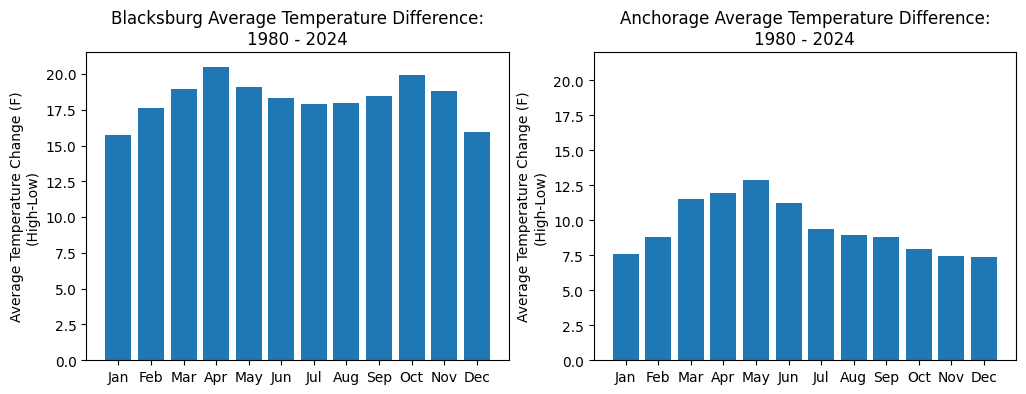

In [5]:
import matplotlib.pyplot as plt 

# Filter the data
anch_weather = weather[weather['city'] == 'Anchorage'].copy()

# Transformation - adding a new column of data
#  difference of the max and min temps
anch_weather['daily_diff'] = (anch_weather['temp max'] - anch_weather['temp min'])

# Grouping by month and aggregate mean over the temp difference
a_yearly_diff = anch_weather.groupby("month")['daily_diff'].mean()
b_yearly_diff = bburg_weather.groupby("month")["daily_diff"].mean()

# Changing the indecies from numbers to abbrev months
yearly_diff.index = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Matplotlib Bar chart - 2 bar charts next to each other
#  each has a title, x and y axis label
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))

ax1.bar(yearly_diff.index, b_yearly_diff)
ax1.set_title("Blacksburg Average Temperature Difference:\n1980 - 2024")
ax1.set_ylabel("Average Temperature Change (F)\n(High-Low)")

ax2.bar(yearly_diff.index, a_yearly_diff)
ax2.set_title("Anchorage Average Temperature Difference:\n1980 - 2024")
ax2.set_ylabel("Average Temperature Change (F)\n(High-Low)")
ax2.set_ylim([0, 22])

plt.show()

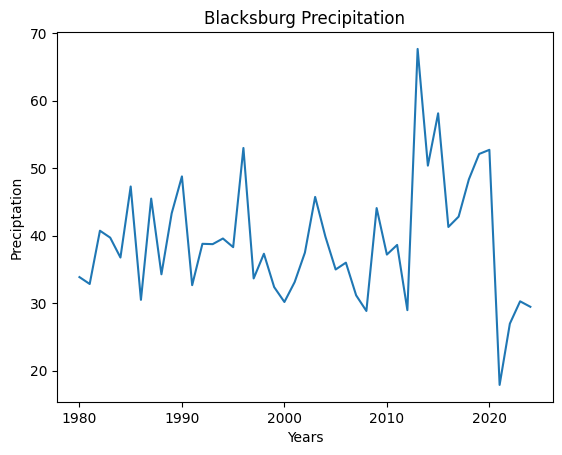

In [6]:
import matplotlib.pyplot as plt

# Filter the data
bburg_weather = weather[weather['city'] == 'Blacksburg'].copy()

# Group by year and aggregate sum, then convert to inches
yearly_precip = (bburg_weather.groupby('year')['precipitation'].sum() / 25.4)
yearly_precip[2024] *= 25.4

# Matplotlib Line plot with title, x and y axis labels
fig, ax = plt.subplots()
ax.plot(yearly_precip)

ax.set_title("Blacksburg Precipitation")
ax.set_xlabel("Years")
ax.set_ylabel("Preciptation")

plt.show()

In [1]:
# Same graph as above with improvements
#  (A graph reference for Project 5: bike share)
import matplotlib.pyplot as plt

# Filter the data
bburg_weather = weather[weather['city'] == 'Blacksburg'].copy()

# Group by year, aggregate sum, convert to inches
yearly_precip = bburg_weather.groupby('year')['precipitation'].sum() / 25.4
yearly_precip[2024] *= 25.4

# Finding the max point of the dataset
max_precip = yearly_precip.max()
max_year = yearly_precip.idxmax()

# just in case there are other settings set in other cells
plt.style.use('default')

# Matplotlib Line plot with:
#  title, x and y axis labels, legend, and annontation
fig, ax = plt.subplots()
ax.plot(yearly_precip, 
        label=['Avg Precip'], 
        marker='.',
        )
ax.set_title("Blacksburg Yearly Average Precipitation:\n1980 - 2024",
          fontweight='bold')
ax.set_xlabel("Years", fontweight='bold')
ax.set_ylabel("Average Precipitation (inches)", fontweight='bold')
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1))

#ax.set_ylim([0, 70])
ax.grid()

# Annontation - max y value of the line plot
ax.annotate(f"Highest Avg Precip:\n{max_year}, {max_precip:.1f} (in)",
            xy=(max_year, max_precip),
            xytext=(max_year + 15, max_precip - 10),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10,
            fontweight='bold'
            )


plt.show()

NameError: name 'weather' is not defined

### Seaborn

yearly_precip datatype:  <class 'pandas.core.frame.DataFrame'>
seaborn works with Pandas DataFrames


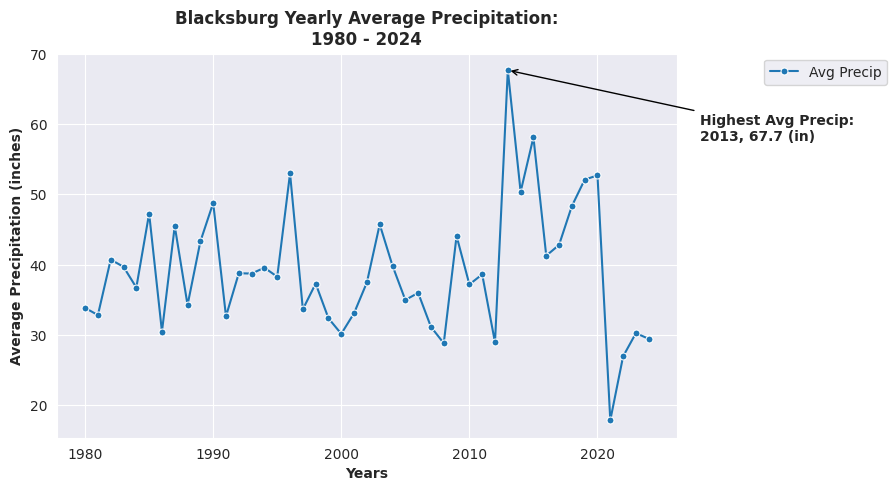

In [7]:
# Same graph as above using Seaborn instead of Matplotlib
import seaborn as sns

bburg_weather = weather[weather['city'] == 'Blacksburg'].copy()

yearly_precip = (bburg_weather.groupby(['year'])["precipitation"].sum() / 25.4)
yearly_precip[2024] *= 25.4
yearly_precip = yearly_precip.reset_index()
yearly_precip.columns = ['month', 'mean_precip']
print("yearly_precip datatype: ", type(yearly_precip))
print("seaborn works with Pandas DataFrames")

# Find max value
max_idx = yearly_precip['mean_precip'].idxmax()
max_year = yearly_precip.loc[max_idx, 'month']
max_precip = yearly_precip.loc[max_idx, 'mean_precip']

sns.set_style(style='darkgrid') # dark, white, whitegrid, ticks
# sns.set_context("talk") # paper, notebook, talk, poster

# Create the plot and capture the Axes object
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=yearly_precip, x='month', y='mean_precip', 
             marker='.',
             markersize=10,
             label="Avg Precip", 
             ax=ax)

# Set titles and labels
ax.set_title("Blacksburg Yearly Average Precipitation:\n1980 - 2024", fontweight='bold')
ax.set_xlabel("Years", fontweight='bold')
ax.set_ylabel("Average Precipitation (inches)", fontweight='bold')
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1))

# ax.set_ylim([0, 70])
# ax.grid()

# Annotate using the captured Axes object
ax.annotate(f"Highest Avg Precip:\n{max_year}, {max_precip:.1f} (in)",
            xy=(max_year, max_precip),
            xytext=(max_year + 15, max_precip - 10),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10,
            fontweight='bold'
           )

plt.show()


### Plotly

In [ ]:
# Same as the Matplotlib graph above but using Plotly
#  (A graph reference for Project 5: bike share)
import plotly.express as px

#####
# These lines are needed when exporting the notebook to html
# import plotly.io as pio

# pio.renderers.default = "notebook_connected"
#####

# Filter the data
bburg_weather = weather[weather['city'] == 'Blacksburg'].copy()

# Group by year, aggregate sum, convert to inches
yearly_precip = bburg_weather.groupby(['year'])['precipitation'].sum() / 25.4
yearly_precip[2024] = yearly_precip[2024] * 25.4

# Finding the max point of the dataset
max_precip = yearly_precip.max()
max_year = yearly_precip.idxmax()

# Plotly Line plot with
#  title, x and y axis label, legend, and annotation
fig = px.line(yearly_precip, 
              #title="<b>Blacksburg Yearly Avg Precipitation: 1980 - 2024</b>", #tells to be bold
              markers=True,
              )
fig.update_layout(title="<b>Blacksburg Yearly Avg Precipitation: 1980 - 2024</b>",
                  #title="Blacksburg Yearly Avg Precipitation: 1980 - 2024",
                  title_x=0.5,
                  #width=700,
                  #height=300,
                  #yaxis=dict(range=[0, 70]),
                  
                  xaxis_title="<b>Year</b>",
                  yaxis_title="<b>Avg Precipiation (inches)</b>",
                  legend_title="Avg Precip (in)"
                  )

fig.add_annotation(
    x=max_year,
    y=max_precip,
    text=f"<b>Highest Avg Precip<br>{max_year}, {max_precip:.1f} (in)</b>",
    showarrow=True,
    arrowhead=2,
    ax=100,
    ay=0
)

fig.show()

### Practice Plotting

>1. (Line) Plot the average temperature from 1980 to 2024 (both Blacksburg and Anchorage).
>1. (Bar) Compare the average lowest temperature with the lowest recorded temperature (both Blacksburg and Anchorage).

#### Bar Plots : VT Snow Storm Temperatures

> Old-timers often say that Virginia Tech never used to cancel classes for snow — even when the storms were heavier than what we see today. They recall trudging through deep snowdrifts just to make it to lectures. In this analysis, we’ll compare the minimum and maximum temperatures during the legendary March 1981 snowstorm, which dropped over a foot of snow, with the 2022 storm that led to a rare campus closure.

In [ ]:
import pandas as pd

weather = pd.read_csv("weather.csv")
bburg_weather = weather[weather['city'] == 'Blacksburg'].copy()
bburg_weather['temp avg'] = (bburg_weather['temp min'] + 
                             bburg_weather['temp morning'] + 
                             bburg_weather['temp afternoon'] + 
                             bburg_weather['temp evening'] + 
                             bburg_weather['temp night'] + 
                             bburg_weather['temp max']) / 6

# Filtering for the 2022 Jan 16-18 Snow Storm
y22 = bburg_weather.groupby(['year', 'month', 'day']).agg({
    'temp min': "mean", 
    'temp max': "mean", 
    'temp avg': "mean"}).round(0).reset_index()
y22 = y22[(y22['year'] == 2022) & 
          (y22['month'] == 1) & 
          ((y22['day'] == 16) | (y22['day'] == 17) | (y22['day'] == 18))]
display(y22)

# Filtering for the 1981 Mar 22-24 Snow Storm
y81 = bburg_weather.groupby(['year', 'month', 'day']).agg({
    'temp min': "mean", 
    'temp max': "mean", 
    'temp avg': "mean"}).round(0).reset_index()
y81 = y81[(y81['year'] == 1981) & 
          (y81['month'] == 3) & 
          ((y81['day'] == 22) | (y81['day'] == 23) | (y81['day'] == 24))]
display(y81)


**Creating Bar Plots to compare Minimum and Maximum Temperatures**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#print(plt.style.available)
plt.style.use('seaborn-v0_8-darkgrid')

# Helper function to add labels
def add_labels(bars, ax):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height,
                f'{height:.0f}', ha='center', va='bottom')


# 2022 Jan 16-18 min & max temps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
w = 1
den = 3
x = np.arange(0, 3)
bars = ax1.bar(x, y22['temp min'], w/den, label='Min Temp')
add_labels(bars, ax1)

bars = ax1.bar(x+w/den, y22['temp max'], w/den, label='Max Temp')
add_labels(bars, ax1)

ax1.set_title("2022 Blacksburg VA Min and Max Temps\n(7.6 in of snow)")
ax1.set_ylabel("Min and Max Temps (F)")
# yaxis bar labels to include the month and day
yLabels = list(y22['day'].astype(str))
for i in range(len(yLabels)):
    yLabels[i] = "Jan " + yLabels[i]
yLabels[1] = yLabels[1] + "\n(Mon)"
ax1.set_xticks(x + .2, yLabels)
# creating the same y-axis range
ax1.set_ylim([0, 50.5])
ax1.legend(loc='upper left')


# 1981 Mar 22-24 min & max temps
bars = ax2.bar(x, y81['temp min'], w/den, label='Min Temp')
add_labels(bars, ax2)

bars = ax2.bar(x+w/den, y81['temp max'], w/den, label='Max Temp')
add_labels(bars, ax2)

ax2.set_title("1981 Blacksburg VA Min and Max Temps\n(13.0 in of snow)")
ax2.set_ylabel("Min and Max Temps (F)")
# yaxis bar labels to include the month and day
yLabels = list(y81['day'].astype(str))
for i in range(len(yLabels)):
    yLabels[i] = "Mar " + yLabels[i]
yLabels[1] = yLabels[1] + "\n(Mon)"
ax2.set_xticks(x + .2, yLabels)
# creating the sam y-axis range
ax2.set_ylim([0, 50.5])
ax2.legend(loc='upper left')

plt.show()
